In [1]:
using MPSKit, TensorKit, Plots, JLD2, LaTeXStrings

In [2]:
D = 20

20

In [3]:
σˣ = TensorMap(ComplexF64[0 1; 1 0], ℂ^2 ← ℂ^2)
σʸ = TensorMap(ComplexF64[0 -im; im 0], ℂ^2 ← ℂ^2)
σᶻ = TensorMap(ComplexF64[1 0; 0 -1], ℂ^2 ← ℂ^2)
Iden = TensorMap(ComplexF64[1 0; 0 1], ℂ^2 ← ℂ^2)

2←2 TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}:
 codomain: ⊗(ℂ^2)
 domain: ⊗(ℂ^2)


In [6]:
function corr_len_and_ee(D_min, D_max, step)
    """
    Compute the entanglement entropy and correlation length as a function of the bond dimension.
    """
    ans = Array{Float64, 2}(undef, floor(Int, (D_max - D_min)/step) + 1, 2)
    idx = 1
    for dim in D_min:step:D_max
        ψ_init = InfiniteMPS(ℂ^2, ℂ^dim)
        ψ_gs, _ = find_groundstate(ψ_init, ham, VUMPS())
        EE = entropy(ψ_gs)
        ξ = correlation_length(ψ_gs)
        ans[idx, 1] = EE[1]
        ans[idx, 2] = ξ
        idx += 1
    end
    return ans
end

corr_len_and_ee (generic function with 1 method)

In [7]:
J = 1.0
gᶻ = 0.01
gˣ = 1.06
ham_density = - (J * σᶻ ⊗ σᶻ) - (gˣ * σˣ + gᶻ * σᶻ) ⊗ Iden

2×2←2×2 TensorMap{ComplexF64, ComplexSpace, 2, 2, Vector{ComplexF64}}:
 codomain: (ℂ^2 ⊗ ℂ^2)
 domain: (ℂ^2 ⊗ ℂ^2)


In [8]:
chain = PeriodicVector([ℂ^2])
ham = InfiniteMPOHamiltonian(chain, 1 => - (gˣ * σˣ + gᶻ * σᶻ), (1, 2) => - J * σᶻ ⊗ σᶻ)

single site InfiniteMPOHamiltonian{MPSKit.JordanMPOTensor{ComplexF64, ComplexSpace, Union{BraidingTensor{ComplexF64, ComplexSpace}, TensorMap{ComplexF64, ComplexSpace, 2, 2, Vector{ComplexF64}}}, TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 2, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}}}:
╷  ⋮
┼ W[1]: JordanMPOTensor{ComplexF64, ComplexSpace, Union{BraidingTensor{ComplexF64, ComplexSpace}, TensorMap{ComplexF64, ComplexSpace, 2, 2, Vector{ComplexF64}}}, TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 2, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}}(((ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1) ⊗ ⊞(ℂ^2)) ← (⊞(ℂ^2) ⊗ (ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1)), SparseBlockTensorMap{Union{BraidingTensor{ComplexF64, ComplexSpace}, TensorMap{ComplexF64, ComplexSpace, 2, 2, Vector{ComplexF64}}}, ComplexF64, ComplexSpace, 2, 2, 4}(Dict{CartesianIndex{4}, Unio

In [65]:
ψ_0 = InfiniteMPS(ℂ^2, ℂ^D)
ψ_gs, _ = find_groundstate(ψ_0, ham, VUMPS())

[ Info: VUMPS init:	obj = -1.058545296993e+00	err = 3.2397e-01
[ Info: VUMPS   1:	obj = -1.315273710188e+00	err = 1.6181634124e-02	time = 0.01 sec
[ Info: VUMPS   2:	obj = -1.317981244559e+00	err = 2.0561236793e-03	time = 0.02 sec
[ Info: VUMPS   3:	obj = -1.318010318867e+00	err = 5.0775237239e-05	time = 0.02 sec
[ Info: VUMPS   4:	obj = -1.318010331559e+00	err = 4.1109204687e-06	time = 0.01 sec
[ Info: VUMPS   5:	obj = -1.318010331598e+00	err = 7.4960537427e-07	time = 0.01 sec
[ Info: VUMPS   6:	obj = -1.318010331599e+00	err = 1.8951938090e-07	time = 0.01 sec
[ Info: VUMPS   7:	obj = -1.318010331599e+00	err = 6.5831680064e-08	time = 0.01 sec
[ Info: VUMPS   8:	obj = -1.318010331599e+00	err = 2.6266801140e-08	time = 0.01 sec
[ Info: VUMPS   9:	obj = -1.318010331599e+00	err = 1.0297525084e-08	time = 0.01 sec
[ Info: VUMPS  10:	obj = -1.318010331599e+00	err = 4.1064657576e-09	time = 0.02 sec
[ Info: VUMPS  11:	obj = -1.318010331599e+00	err = 1.6620663247e-09	time = 0.01 sec
[ Info: VUMPS

(│   ⋮
│ C[1]: TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[0.778004+0.0im, 0.20469+0.170788im, -0.136822-0.128304im, 0.186157+0.032311im, 0.0443408-0.0954208im, -0.0477874+0.188174im, -0.187953-0.0553462im, 0.0810627-0.0569857im, 0.0882091+0.0116534im, -0.151244+0.0390593im  …  0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 2.08964e-7+0.0im], ℂ^20 ← ℂ^20)
├── AL[1]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.397382+0.425874im, -0.000344262+0.116049im, -0.0161422-0.0303041im, 0.194123+0.0346853im, 0.0529646+0.0503707im, -0.0293871-0.0665232im, 0.0158963+0.022253im, 0.0409882+0.0175121im, -0.0442547+0.00366417im, -0.0654349+0.00444689im  …  -0.087407-0.0716164im, 0.14886-0.140348im, -0.056834+0.0255393im, 0.0525039+0.0307482im, -0.0534208+0.117917im, 0.0175433-0.0923616im, 0.228888+0.00653192im, 0.0248272+0.00696424im, 0.0509744-0.0151437im, -0.041544+0.0706803im], (ℂ^20 ⊗ ℂ^2

In [66]:
entropy(ψ_gs)

1-element Vector{Float64}:
 0.1742543105190146

In [67]:
correlation_length(ψ_gs)

5.561353109369225

The relevant physical parameter is
\begin{equation}
\eta_{\text{latt}} = \frac{g_x - 1}{|h_z|^{8/15}}
\end{equation}

# Dispersion relation 

We can obtain the dispersion relation using the QuasiparticleAnsatz()

In [82]:
Δp = 0.05
mom = 0:Δp:0.6

0.0:0.05:0.6

In [83]:
energies, states = excitations(ham, QuasiparticleAnsatz(), mom, ψ_gs; num = 1);

[ Info: Found excitations for momentum = 0.0
[ Info: Found excitations for momentum = 0.05
[ Info: Found excitations for momentum = 0.1
[ Info: Found excitations for momentum = 0.15
[ Info: Found excitations for momentum = 0.2
[ Info: Found excitations for momentum = 0.25
[ Info: Found excitations for momentum = 0.3
[ Info: Found excitations for momentum = 0.35
[ Info: Found excitations for momentum = 0.4
[ Info: Found excitations for momentum = 0.45
[ Info: Found excitations for momentum = 0.5
[ Info: Found excitations for momentum = 0.55
[ Info: Found excitations for momentum = 0.6


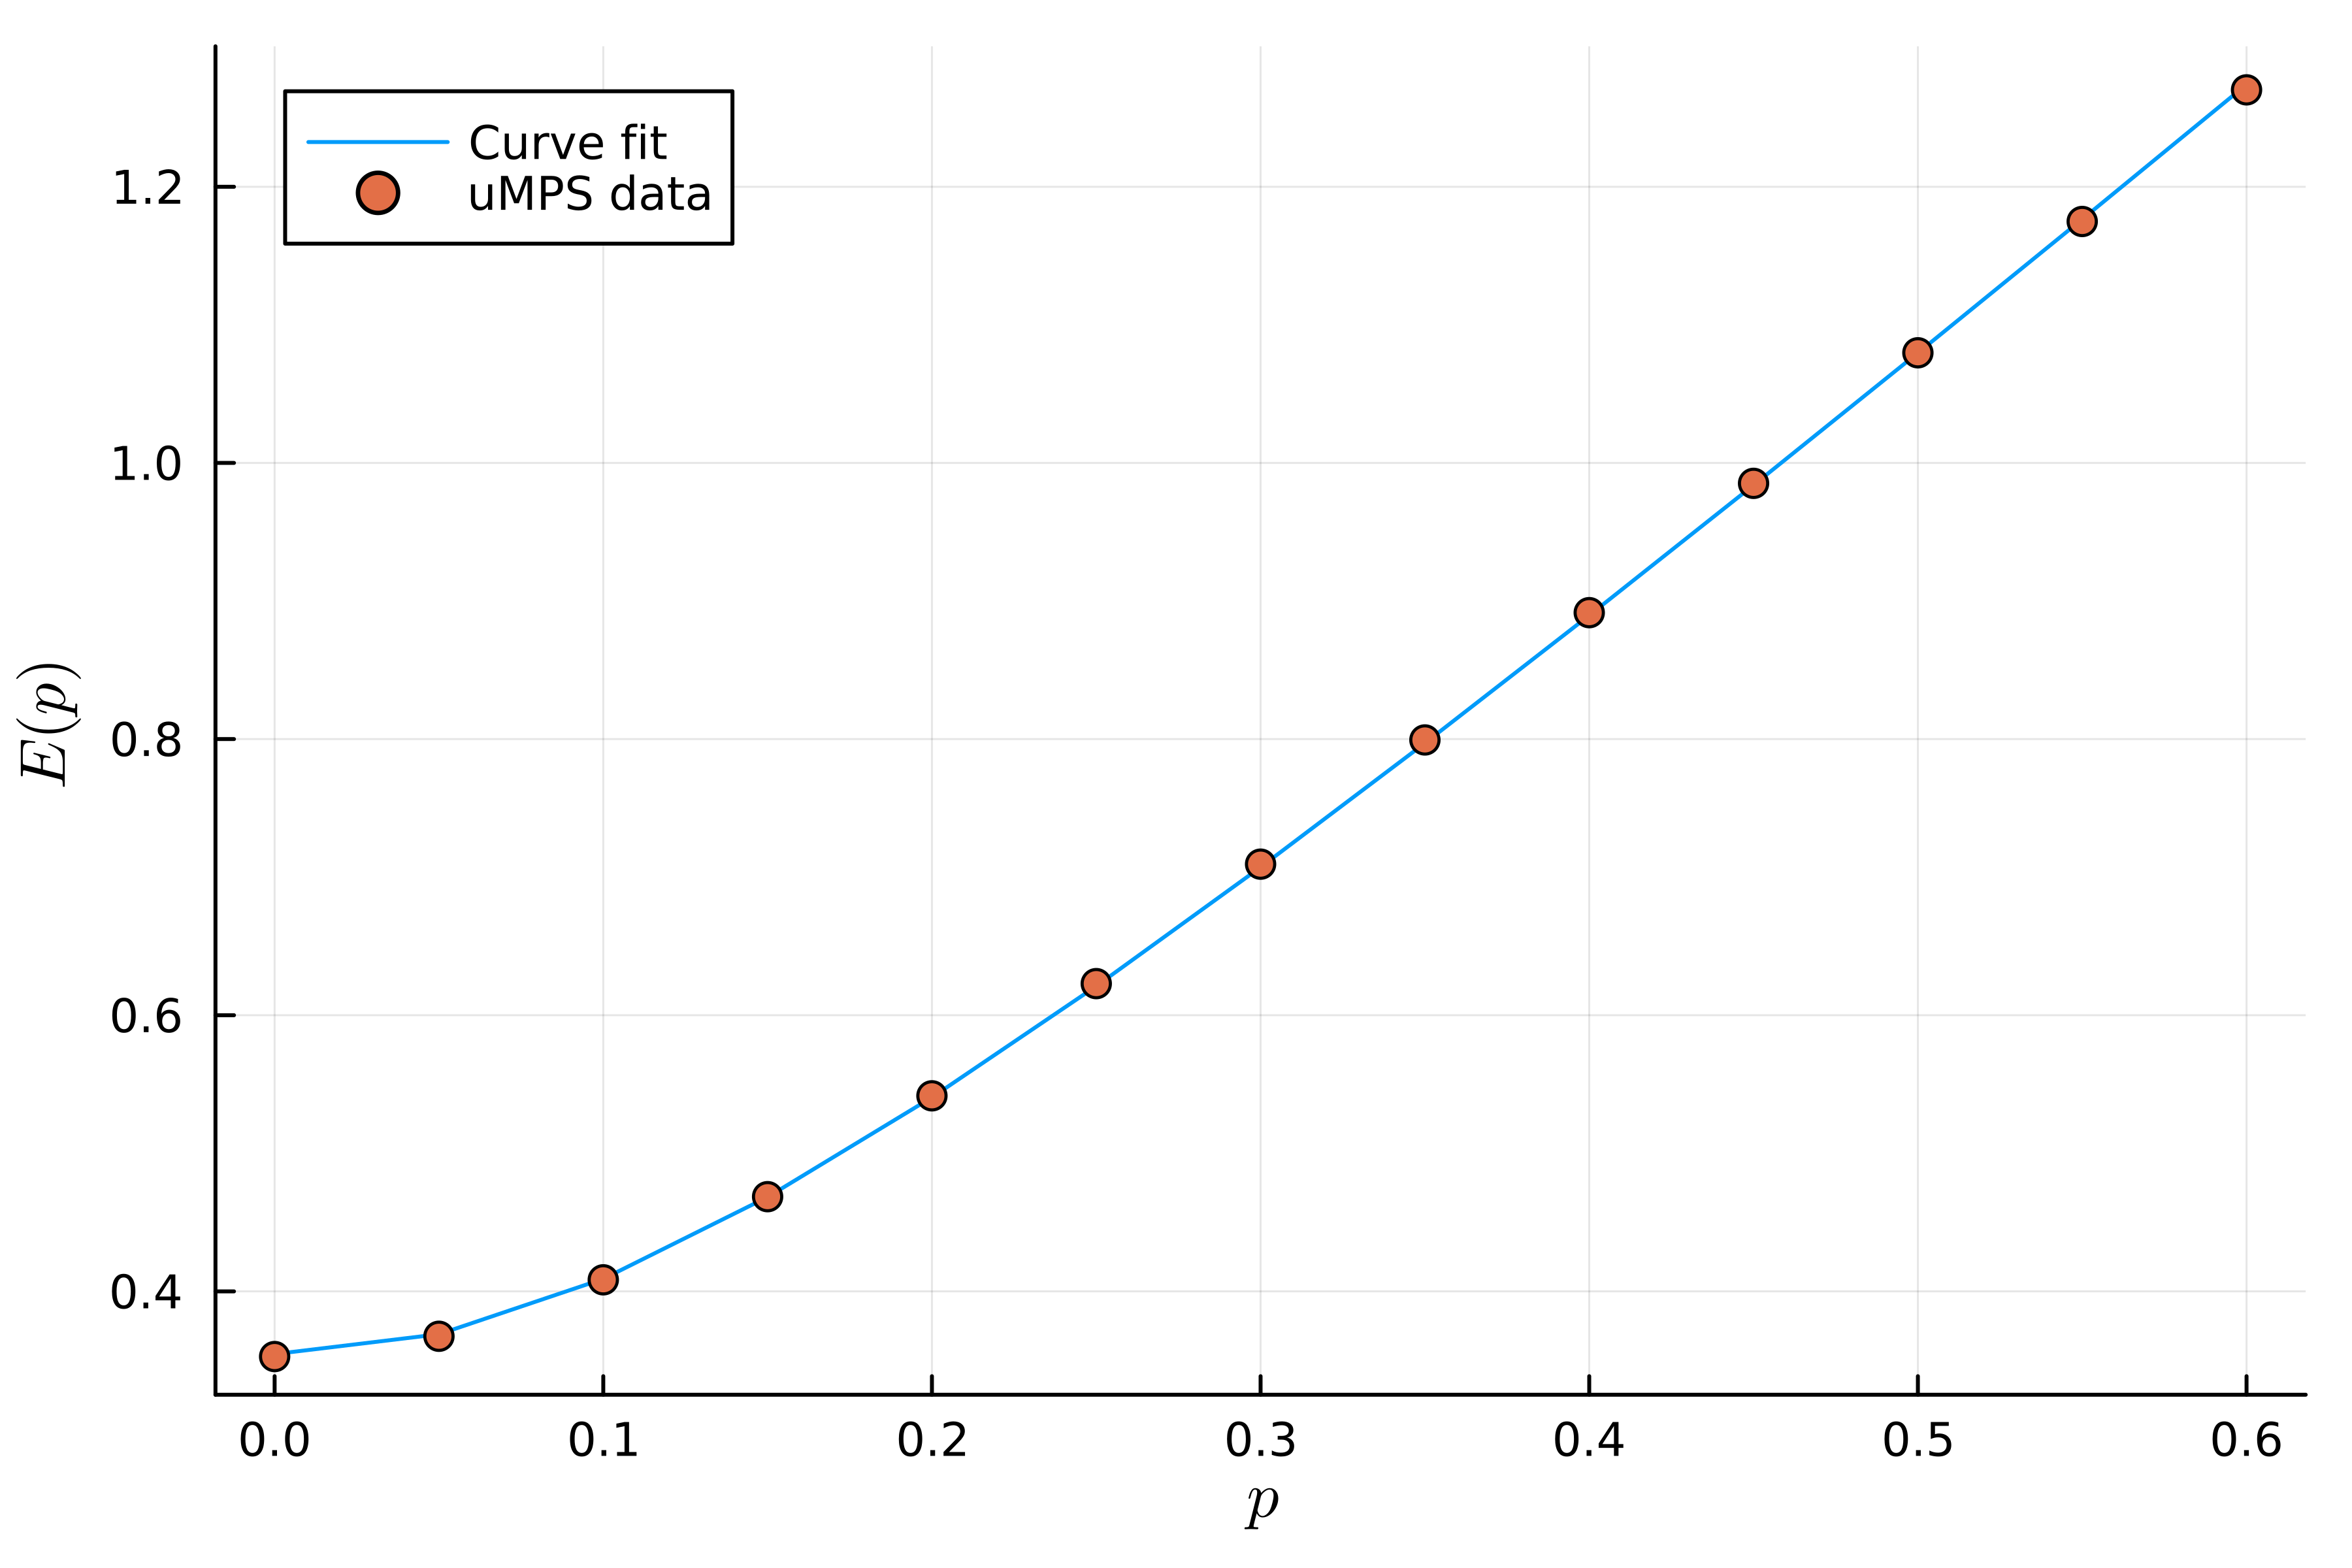

In [86]:
plot(mom, spec_true, xlabel=L"p", ylabel=L"E(p)", label="Curve fit")
scatter!(mom, energies, dpi=600, xlabel=L"p", ylabel=L"E(p)", label="uMPS data")

In [87]:
savefig("dispersion_fit_IFT.png")

"/home/ujjwal/MPSJulia/ift/dispersion_fit_IFT.png"

In [72]:
function η_lat(g_x, g_z)
    return (g_x - 1) / (g_z)^(8 / 15)
end

η_lat (generic function with 1 method)

In [88]:
using LsqFit
using Statistics  # for mean

# Your model: k is a vector of k-values, p = [m, c]
model(k, p) = sqrt.(p[1]^2 * p[2]^4 .+ k.^2 .* p[2]^2)
#                m^2 c^4           +   k^2 c^2

k_values = convert(Array, mom)     # lattice momentum (Vector)
p_values = energies[:, 1]          # lattice energy (Vector)

# Initial guess for [m, c]
p0 = [1.0, 1.0]

# Perform the fit
fit = curve_fit(model, k_values, p_values, p0)

# Extract fitted parameters
m_fit, c_fit = coef(fit)
println("Fit parameters:")
println("  m = $m_fit")
println("  c = $c_fit")

# ---------- goodness of fit stuff ----------

resid = residuals(fit)                 # y - f(x, p)
SSE   = sum(abs2, resid)               # sum of squared errors

ȳ     = mean(p_values)
SST   = sum((p_values .- ȳ).^2)       # total sum of squares

n = length(p_values)                   # number of data points
p = length(coef(fit))                  # number of parameters
dof = n - p                            # degrees of freedom

R2     = 1 - SSE / SST
R2_adj = 1 - (SSE / (n - p)) / (SST / (n - 1))
χ2_red = SSE / dof

stderr = stderror(fit)                 # standard errors of [m, c]

println("\nGoodness of fit:")
println("  SSE        = $SSE")
println("  R²         = $R2")
println("  R² (adj)   = $R2_adj")
println("  χ²_red     = $χ2_red")
println("  dof        = $dof")
println("  stderr(m)  = $(stderr[1])")
println("  stderr(c)  = $(stderr[2])")


Fit parameters:
  m = -0.08523840271658409
  c = 2.039596980570574

Goodness of fit:
  SSE        = 4.420963927411137e-5
  R²         = 0.9999631087845379
  R² (adj)   = 0.9999597550376778
  χ²_red     = 4.019058115828307e-6
  dof        = 11
  stderr(m)  = 0.0003697844168199292
  stderr(c)  = 0.002004595929507688


In [74]:
function spec_true(p)
    m = m_fit
    c = c_fit
    return sqrt(m^2 * c^4 + p^2 * c^2)
end

spec_true (generic function with 1 method)

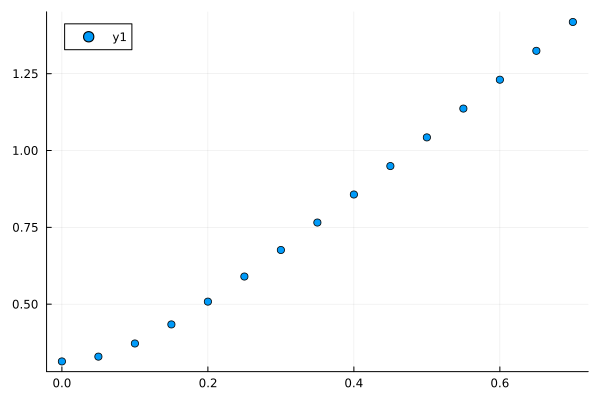

In [363]:
scatter(mom, energies)

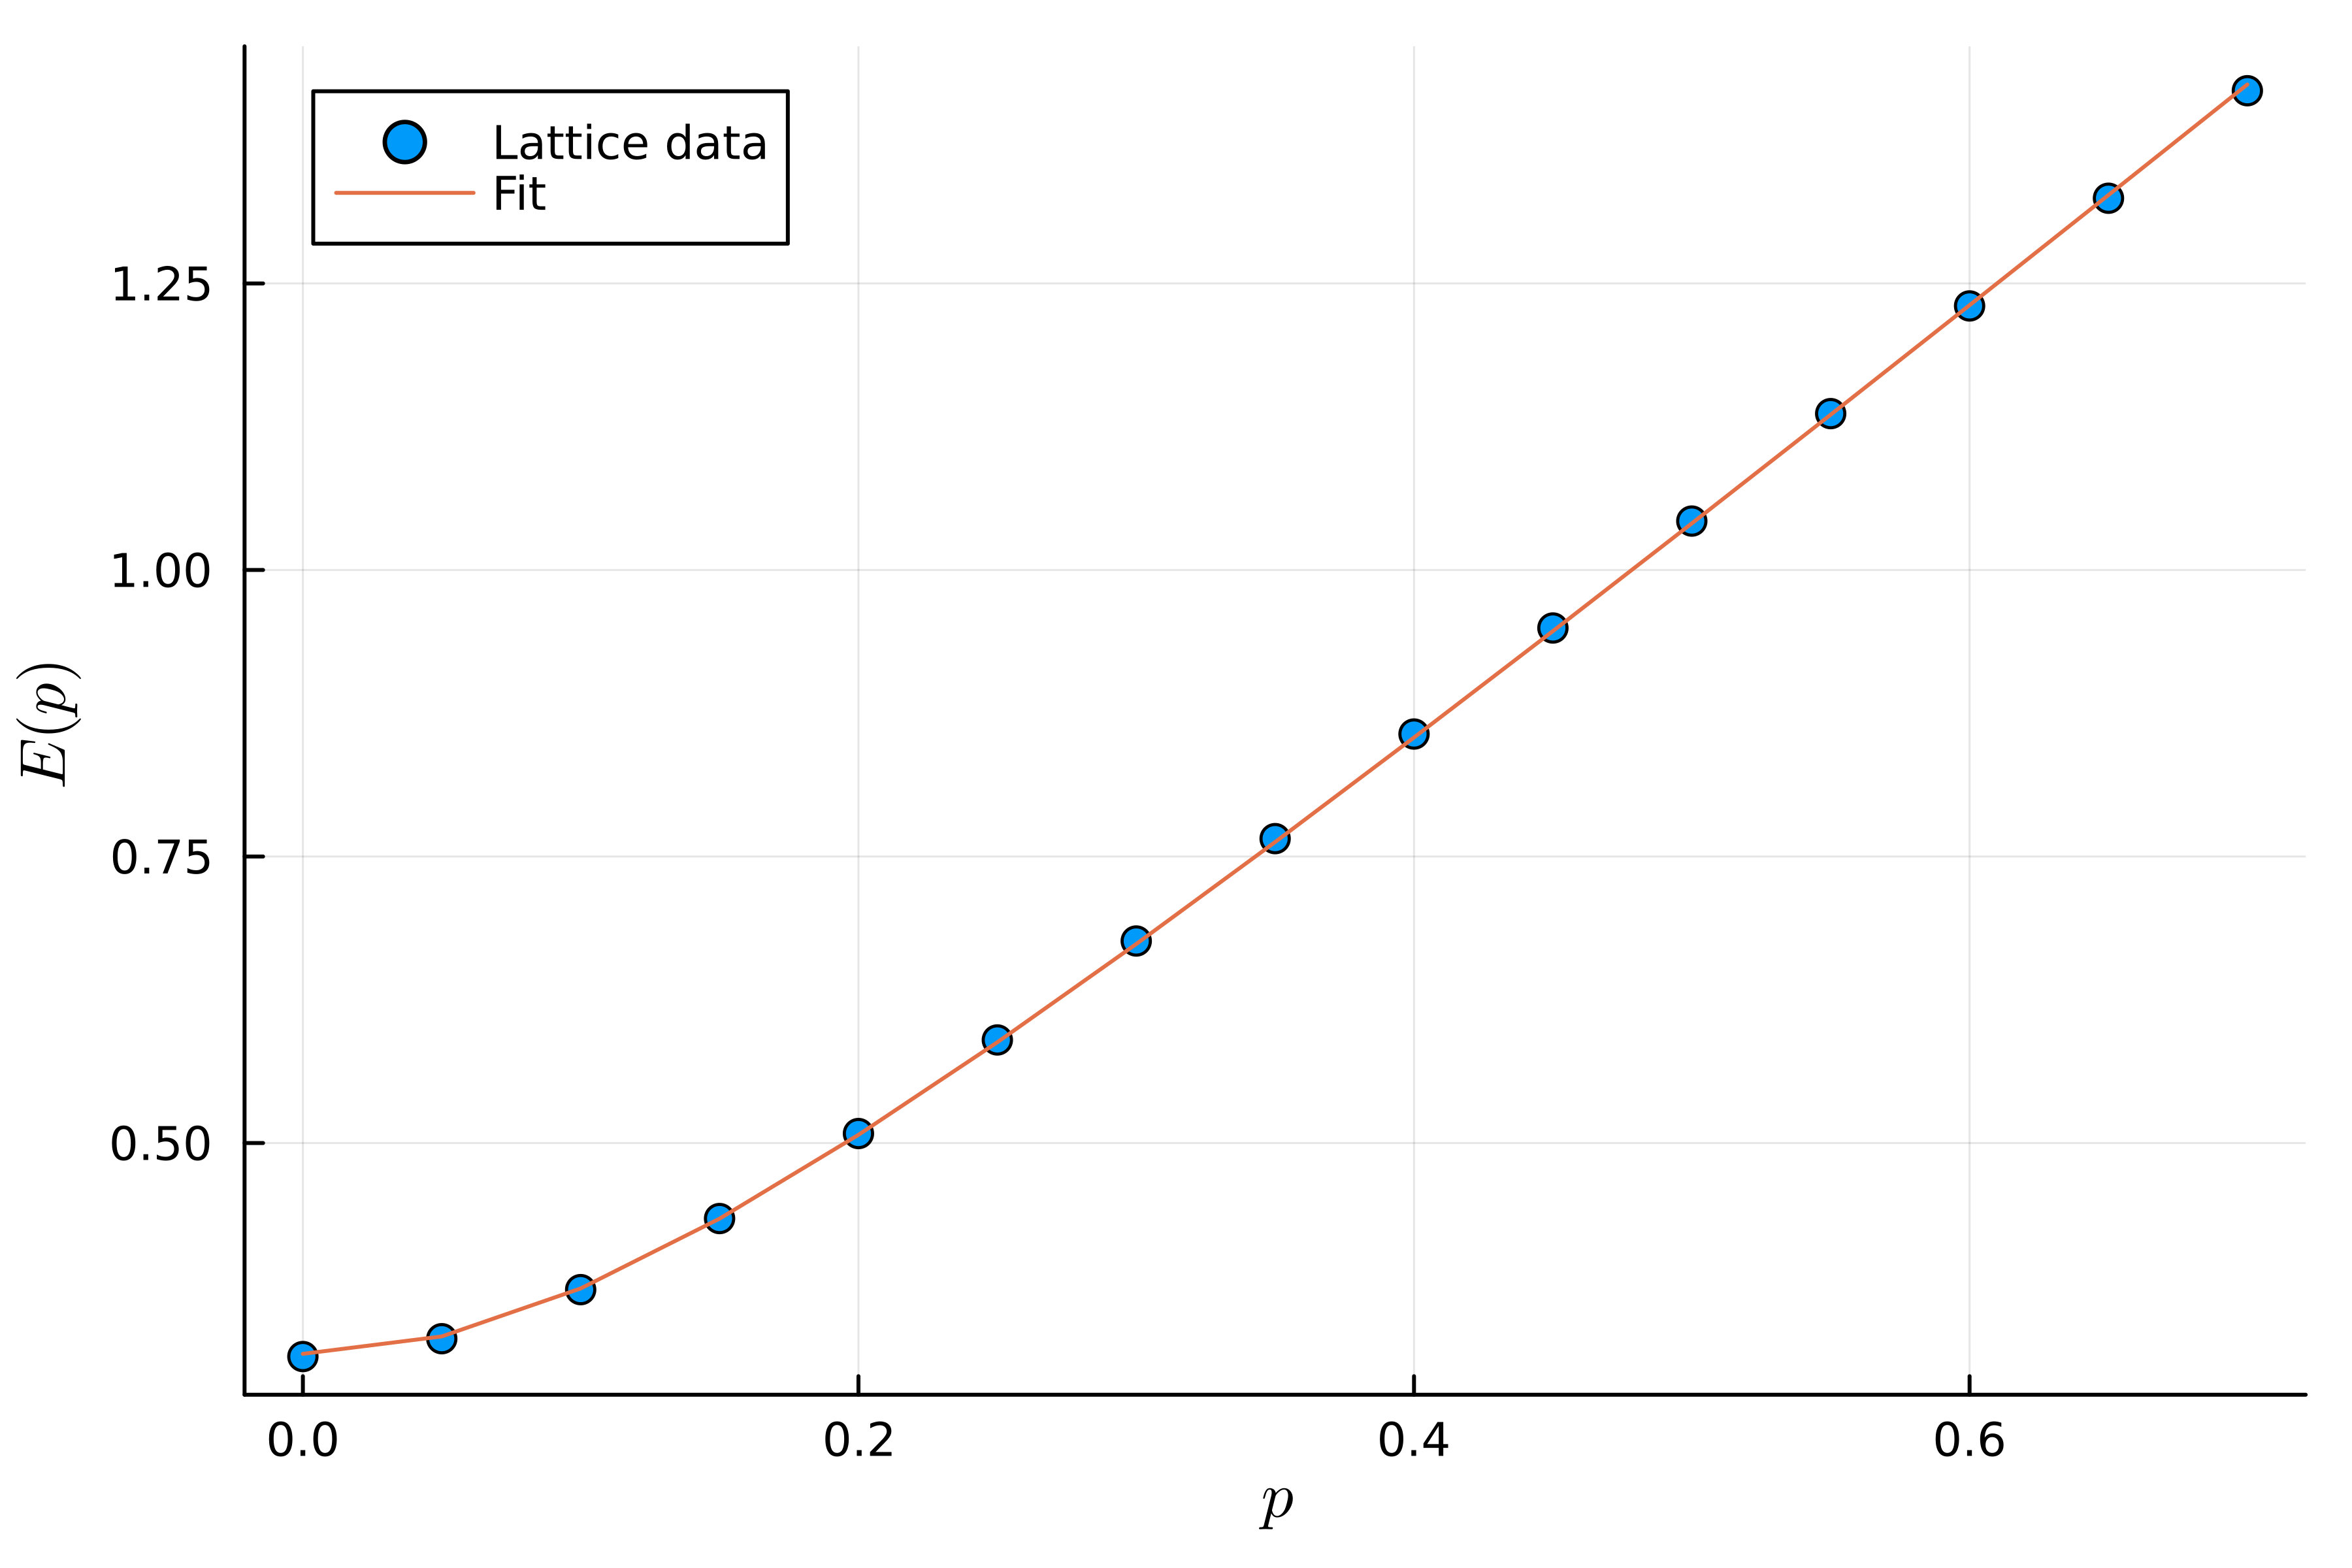

In [364]:
scatter(mom, energies, label="Lattice data", xlabel=L"p", ylabel=L"E(p)")
plot!(mom, spec_true, label="Fit", dpi=600)

In [423]:
sqrt((0.693^2 - m_fit^2 * c_fit^4) / c_fit^2)

0.29244229606239064

# scattering with local disturbance

In [285]:
σ⁺ = σˣ + im * σʸ
σ⁻ = σˣ - im * σʸ

2←2 TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}:
 codomain: ⊗(ℂ^2)
 domain: ⊗(ℂ^2)


In [287]:
@tensor excite[a, b; c] := σ⁺[b; d] * ψ_gs.AC[][a, d; c]

10×2←10 TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}:
 codomain: (ℂ^10 ⊗ ℂ^2)
 domain: ⊗(ℂ^10)


In [288]:
L = 100 # number of lattice sites

100

In [289]:
ψ_window = WindowMPS(ψ_gs, L)

WindowMPS{TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}}(│   ⋮
│ C[1]: TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[0.834102+0.0im, -0.211315-0.0244249im, -0.143791+0.0706147im, 0.180728-0.0314147im, 0.0827924+0.294636im, 0.0617661-0.0832814im, -0.00267968+0.127073im, -0.0488999-0.030284im, -0.00725127+0.0705023im, -0.108778-0.103109im  …  0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 2.03491e-5+0.0im], ℂ^10 ← ℂ^10)
├── AL[1]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.505488+0.503628im, -0.0507814-0.0625208im, 0.0433114-0.0718507im, 0.025431+0.0627627im, 0.0112572+0.0392137im, -0.032555+0.0356898im, -0.0446922+0.038493im, -0.00852658+0.00108641im, -0.0171584+0.0481176im, -0.0446046-0.0047894im  …  -0.145911+0.0536188im, 0.242248-0.0875461im, 0.132547+0.0933784im, 0.0424303-0.161706im, 0.135567+0.

In [290]:
T = 100 # total lattice time

100

In [291]:
ψ_window.AC[30] = excite
ψ_window.AC[70] = excite

10×2←10 TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}:
 codomain: (ℂ^10 ⊗ ℂ^2)
 domain: ⊗(ℂ^10)


In [292]:
σᶻ_exp = Array{Float64, 2}(undef, T, L);
energy_expectation_value = Array{Float64, 2}(undef, T, L);

In [293]:
for i in 1:L-1
    σᶻ_exp[1, i] = real(expectation_value(ψ_window, i => σᶻ))
    energy_expectation_value[1, i] = real(expectation_value(ψ_window, (i, i + 1) => ham_density))
end
σᶻ_exp[1, L] = real(expectation_value(ψ_window, L => σᶻ))

0.5716109786640526

In [296]:
ψ_window.AC[100]

10×2←10 TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}:
 codomain: (ℂ^10 ⊗ ℂ^2)
 domain: ⊗(ℂ^10)


In [297]:
ψ_window

WindowMPS{TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}, TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}}(│   ⋮
│ C[1]: TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[0.834102+0.0im, -0.211315-0.0244249im, -0.143791+0.0706147im, 0.180728-0.0314147im, 0.0827924+0.294636im, 0.0617661-0.0832814im, -0.00267968+0.127073im, -0.0488999-0.030284im, -0.00725127+0.0705023im, -0.108778-0.103109im  …  0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 0.0+0.0im, 2.03491e-5+0.0im], ℂ^10 ← ℂ^10)
├── AL[1]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.505488+0.503628im, -0.0507814-0.0625208im, 0.0433114-0.0718507im, 0.025431+0.0627627im, 0.0112572+0.0392137im, -0.032555+0.0356898im, -0.0446922+0.038493im, -0.00852658+0.00108641im, -0.0171584+0.0481176im, -0.0446046-0.0047894im  …  -0.145911+0.0536188im, 0.242248-0.0875461im, 0.132547+0.0933784im, 0.0424303-0.161706im, 0.135567+0.

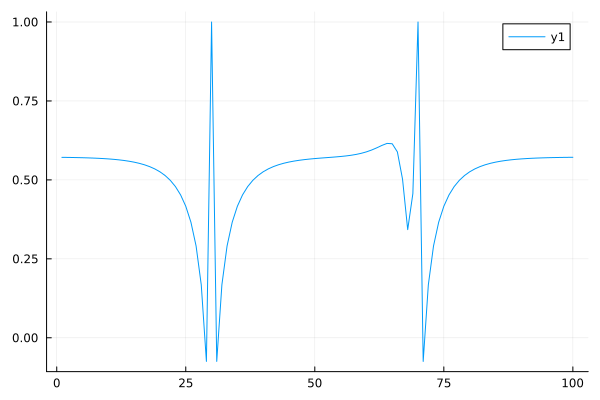

In [294]:
plot(σᶻ_exp[1, :])

In [312]:
dt = 0.1
for i in 2:T
    println("Currently in step $i")
    ψ_window, _ = timestep(ψ_window, ham, (i - 1) * dt, dt, TDVP())
    for j in 1:L-1
        energy_expectation_value[i, j] = real(expectation_value(ψ_window, (j, j + 1) => ham_density))
        σᶻ_exp[i, j] = real(expectation_value(ψ_window, j => σᶻ))
    end
    σᶻ_exp[i, L] = real(expectation_value(ψ_window, L => σᶻ))
end

Currently in step 2
Currently in step 3
Currently in step 4
Currently in step 5
Currently in step 6
Currently in step 7
Currently in step 8
Currently in step 9
Currently in step 10
Currently in step 11
Currently in step 12
Currently in step 13
Currently in step 14
Currently in step 15
Currently in step 16
Currently in step 17
Currently in step 18
Currently in step 19
Currently in step 20
Currently in step 21
Currently in step 22
Currently in step 23
Currently in step 24
Currently in step 25
Currently in step 26
Currently in step 27
Currently in step 28
Currently in step 29
Currently in step 30
Currently in step 31
Currently in step 32
Currently in step 33
Currently in step 34
Currently in step 35
Currently in step 36
Currently in step 37
Currently in step 38
Currently in step 39
Currently in step 40
Currently in step 41
Currently in step 42
Currently in step 43
Currently in step 44
Currently in step 45
Currently in step 46
Currently in step 47
Currently in step 48
Currently in step 49


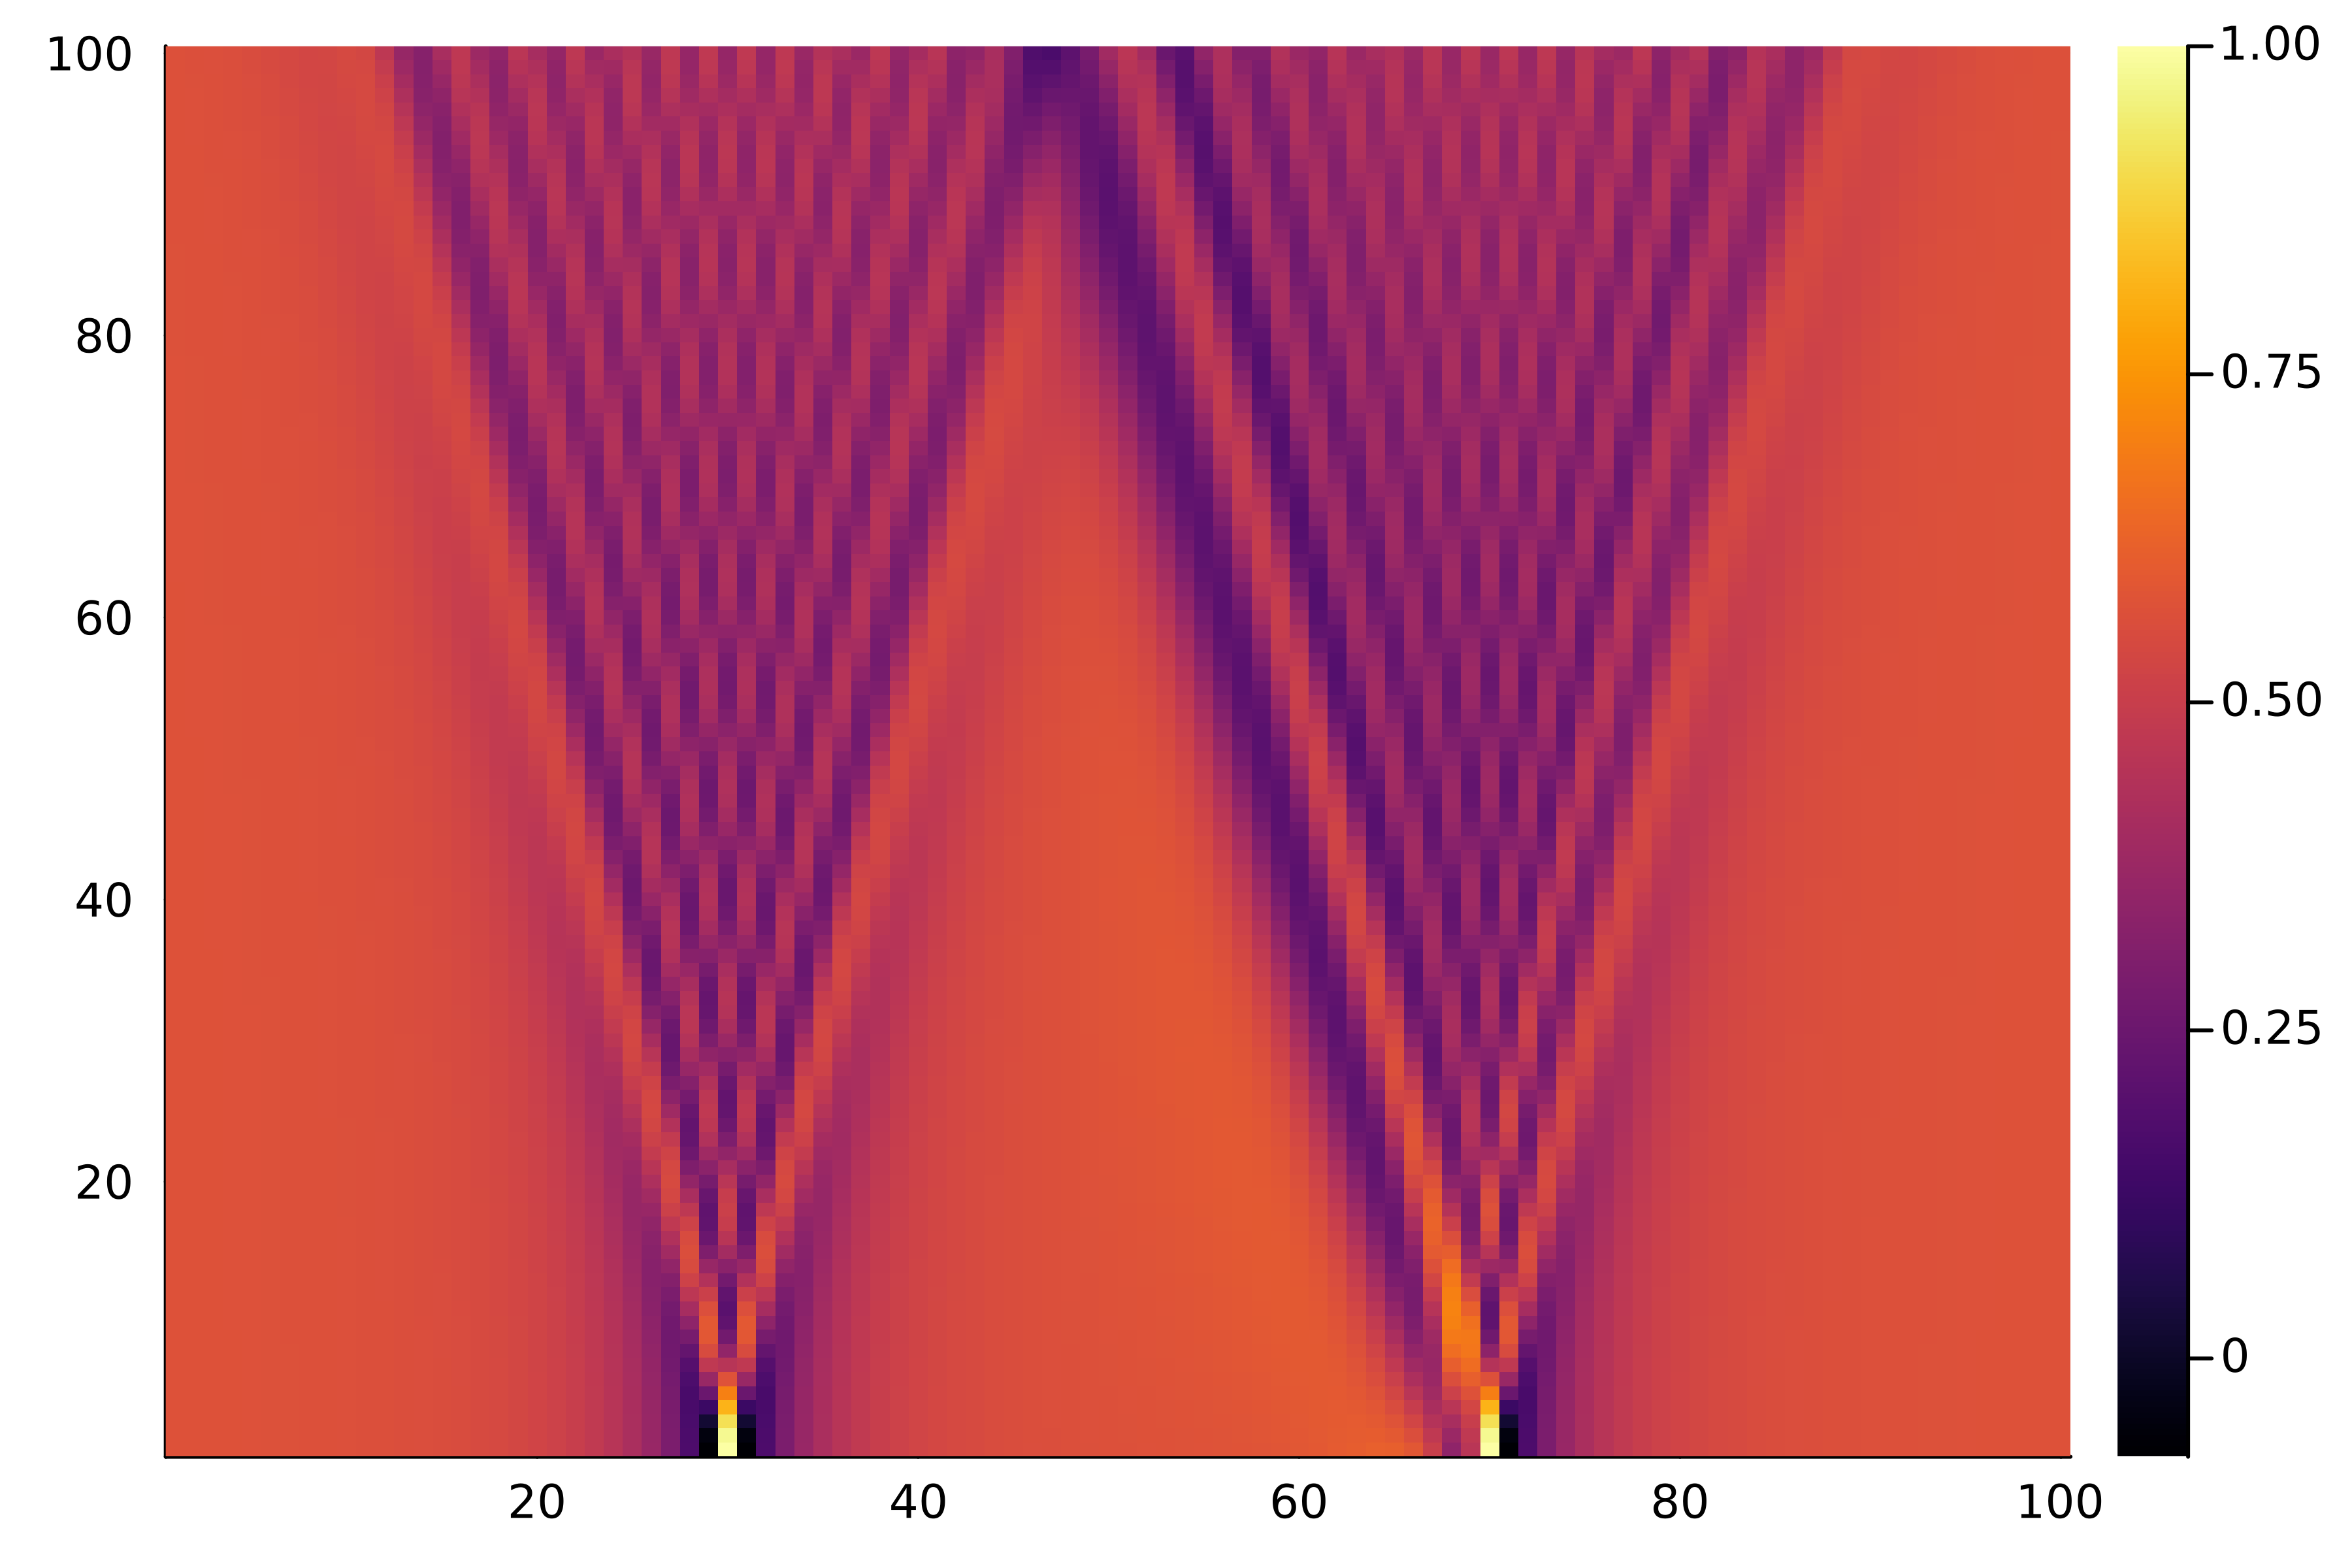

In [314]:
heatmap(σᶻ_exp, dpi = 600)

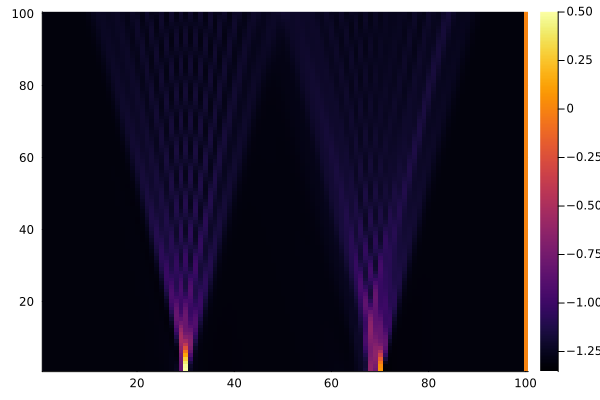

In [157]:
heatmap(energy_expectation_value)